# Dose arrivals and a finite memory

This worked example isolates the social-evidence rule from Sosna et al. (2019).
One fish is active for a prescribed interval; another fish receives its doses
and remembers each one for a fixed time. The receiver stays susceptible so we
can inspect evidence without triggering another escape.

Run these short cells in order. Reusable functions are in [dose.py](dose.py).
The full escape simulation in [simulation.ipynb](simulation.ipynb) uses these
same dose and memory functions. It starts one fish, then compares remembered
social evidence with a threshold to trigger further escapes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from dose import draw_doses, accumulate_doses

## A dose is a packet of evidence

On each timestep an active sender may deliver a packet to its neighbour.
For the directed connection from fish $j$ to fish $i$, the probability is

$$p_{ij} = \mathrm{dose\_rate}\,w_{ij}\,\Delta t.$$

The paper uses a maximum rate of 1000 doses per second and a dose size of 0.001.
A larger connection weight makes a packet more likely; it does not enlarge
that packet. The probability must be at most one. With weights between zero
and one, the timestep below meets that requirement.

In [2]:
## Dose generation and timestep
dt = 0.001
dose_rate = 1000.0
dose_size = 0.001

## One sender and one receiver

Rows receive from columns. Fish 0 sends to fish 1 through an illustrative
connection of weight 0.2. There is no connection in the other direction.
This is a teaching example, not an estimated experimental network.

The probability of a dose on each active timestep is therefore 0.2.
A weight of one would make arrival certain at this timestep and rate.

In [3]:
weights = np.array([[0.0, 0.0], [0.2, 0.0]])
random_seed = 2026

## Combine the incoming packets

For receiver $i$, sum the packets that arrived and divide by $K_i$, the number
of all its incoming neighbours:

$$q_i^k = \frac{\mathrm{dose\_size}}{K_i}
\sum_j \mathbf{1}[j\text{ is active and a packet arrives at step }k].$$

Inactive neighbours still count in $K_i$. An isolated fish receives zero.
Here fish 1 has one neighbour, so each arrival contributes the full dose size.
`draw_doses` implements this calculation. Its `active` mask selects sender
columns; the caller determines which receivers remain susceptible.

There is no additional multiplication by `dt` or the connection weight when
adding a received packet. Both already affect its arrival probability.

## A packet keeps its value until it expires

The active phase lasts 0.5 seconds. Memory lasts 2 seconds, as in Sosna.
The sender stops supplying new packets when its active phase ends. Packets
already received remain fully represented in evidence until they expire.

For example, a packet received at time 0.2 remains in memory until time 2.2.
It then disappears all at once. A three-second observation lets us see all
packets arrive and eventually leave memory.

In [4]:
## Active phase, memory, and observation window
active_duration = 0.5
memory_duration = 2.0
total_time = 3.0

In [5]:
n_steps = round(total_time / dt)
time = np.arange(n_steps) * dt
active_steps = round(active_duration / dt)
memory_steps = round(memory_duration / dt)

`memory_steps` is the number of recent dose samples to keep. For update `step`,
`accumulate_doses` uses these two lines:

```python
window_start = max(0, step - memory_steps + 1)
evidence = dose_history[:, window_start:step + 1].sum(axis=1)
```

`max(0, ...)` handles the beginning of the run, when less than a full window
has elapsed. The final `+ 1` includes the current update because Python slices
exclude their stop index. A dose at update 0 is retained through update
`memory_steps - 1`, and excluded at update `memory_steps`.

This is a sliding sum. There is no exponential leak and no additional Gaussian
noise. Randomness comes from dose arrivals.

In [6]:
dose_history = np.zeros((len(weights), n_steps))
evidence_history = np.zeros_like(dose_history)

## Receive doses, then sum the current memory window

Only fish 0 is active, and only during its prescribed active phase.
Each column records one update; there is no extra initial-state column.

In [7]:
rng = np.random.default_rng(random_seed)
for step in range(n_steps):
    active = np.array([step < active_steps, False])
    dose_history[:, step] = draw_doses(
        weights, active, dt, dose_rate, dose_size, rng,
    )
    evidence_history[:, step] = accumulate_doses(dose_history, step, memory_steps)

## Compare incoming packets with remembered evidence

The upper panel shows each packet received by fish 1. The lower panel shows
their sum within the current memory window. After the sender stops, the sum
stays constant until the earliest packets start expiring. It then falls as
successive packets leave the window, eventually reaching zero.

In [8]:
receiver = 1
fig, (dose_ax, memory_ax) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

In [9]:
dose_ax.vlines(time, 0, dose_history[receiver], color="tab:blue", linewidth=0.8)
dose_ax.set(ylabel="Received dose", title="Packets arriving at the receiver")
dose_ax.axvline(active_duration, color="grey", linestyle="--", label="Sender stops")
dose_ax.legend()

In [10]:
memory_ax.plot(time, evidence_history[receiver], color="tab:orange")
memory_ax.axvline(memory_duration, color="grey", linestyle=":", label="First possible expiry")
memory_ax.set(xlim=(0, total_time), xlabel="Time (s)", ylabel="Remembered dose")
memory_ax.legend()

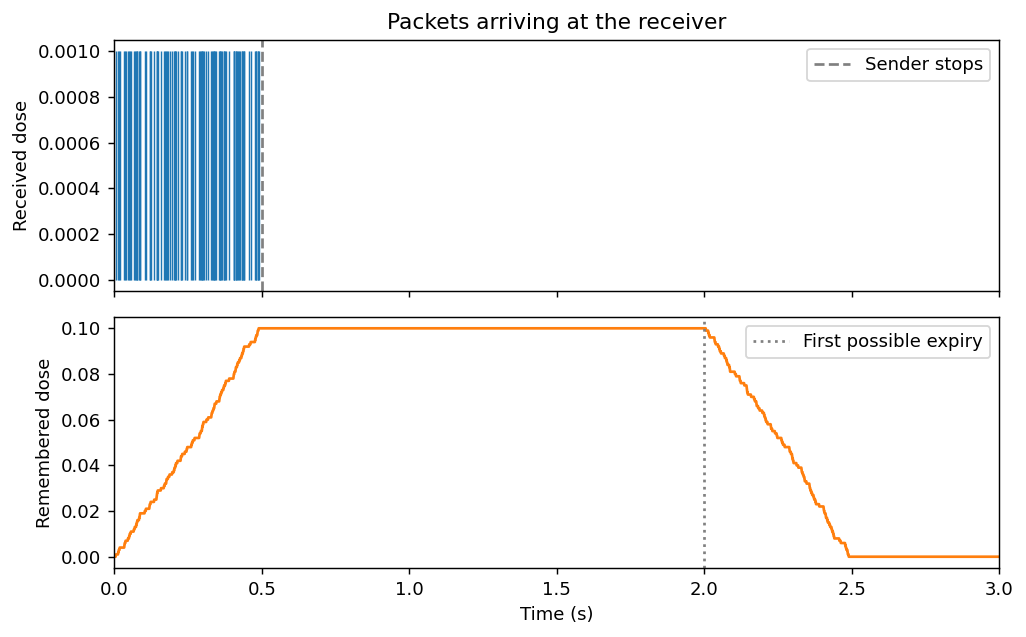

In [11]:
fig.tight_layout()
plt.show()

The main escape simulation starts one active fish and uses the remembered
social dose directly as evidence. Unsheltered fish escape when that evidence
exceeds their individual threshold, drawn once from a uniform distribution.
The main notebook uses Sosna's baseline mean threshold of 0.034 from SI
section 6.3, page 9 (Context 1, before the first exposure, for Fig. 4D).
This is a reference value, not a fit to the notebook's random network.
The isolated example here makes the packet and memory calculations visible
without those behavioral decisions.

Source: Sosna et al. (2019),
[Behavioral Contagion Model, Eq. 1](https://pmc.ncbi.nlm.nih.gov/articles/PMC6789631/).